# LArEventDisplay Example -- COPY ME

#### LArEventDisplay is the 2x2 event display class defined in lar_only_evd.py which uses datasets from `proto_nd_flow`-ed files. For scanning through events, please make a copy of this notebook to use and update locally. Please DO NOT commit changes to this example notebook.

In [1]:
import sys
# Change below to match your path to ndlar_flow/event_display/LAr_evd
sys.path.append('/home/bilal/LAr_evd/ndlar_flow/event_display/LAr_evd/')
sys.path.append('/home/bilal/LAr_evd/h5flow')
mpi4py_path = '/home/bilal/LAr_evd/ndlar_flow/ndlar_flow.venv/lib/python3.10/site-packages'
sys.path.append(mpi4py_path)

from lar2x2_evd import *
plt.ion()

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Hello


#### Inputs to LArEventDisplay:

- `filedir`       (str): path to input file
- `filename`      (str): name of file; must be flow file run through `proto_nd_flow`
- `nhits_min`        (int): minimum number of hits (threshold) for events to be made available (default: 1)
- `nhits_max`        (int): maximum number of hits allowed in event for events to be made available (default: 1e10)
- `ntrigs`        (int): minimum number of external triggers required for events to be made available in interactive display (default=0)
- `show_light`    (bool): whether to show light information in display (default: True, but this takes longer to run)
- `show_colorbars`(bool): if True, shows color bars for charge and light information in 2x2 (default: True)
- `filepath_mx2`  (str): Mx2 file (includ full file path) associated with input flow file (default: None). Note that Mx2 data file timestamps are in UTC, not CT. Also, please note that Mx2 and 2x2 matching is still a work in progress.
- `charge_threshold` (float): threshold for charge hits to be shown (default: None)
- `light_threshold` (float): threshold for light to be shown (default: 150000 ADC counts)
- `beam_only`       (bool): whether to only show beam events (default: False)
- `hist_projection` (bool): if True, hits are binned in a 2D histogram for the 2D charge hit projections. Bins with 0 charge are not displayed. If False, hits are plotted as scatter points for the 2D charge hit projections. For the histograms, sizes are the same for beam, drift, and vertical axes even though drift coordinate resolution may be finer than the resolution in beam/vertical (pixel) dimensions. While binning covers the spaces between modules, it does not cover space external to the modules (only expected for unphysical detector responses or in the case of an event building bug.) (default: True)
- `runsdb`         (str): string giving sqlite3 path to relevant runs database location. The default is 'sqlite:////global/cfs/cdirs/dune/www/data/2x2/DB/RunsDB/releases/mx2x2runs_v0.1_alpha3.sqlite', which reflects the current location of the runs database on NERSC for high purity data runs in July 2024. 

Please note that whether `hist_projection` is True or False, all histogram bins and/or points in all plots (2D and 3D) are slightly larger than pixel pitch-sized by default. This is because the interactive viewer is unable to clearly resolve points/bins reflecting the pixel pitch. However, if you would like to see an event where all points ARE scaled to (approximately) pixel pitch, you can save a PDF version of the event display in which the histogram bins and/or points do reflect pixel pitch using the `p`+`Enter` option described below.

In [24]:
# This set of inputs allows you to look at a data file from the sandbox
# These data do NOT include light information, so please do not set "show_light" to True

file_path = '/home/bilal/LAr_evd/'
# file_name = 'packet-0050017-2024_07_09_00_04_33_CDT.FLOW.hdf5'
# file_name = 'packet-0050017-2024_07_09_00_14_34_CDT.FLOW.hdf5'
# file_name = 'packet-0050017-2024_07_09_00_24_35_CDT.FLOW.hdf5'
# file_name = 'packet-0050017-2024_07_09_00_34_36_CDT.FLOW.hdf5'
# file_name = 'packet-0050017-2024_07_09_00_44_37_CDT.FLOW.hdf5'
# file_name = 'packet-0050017-2024_07_09_00_54_38_CDT.FLOW.hdf5'
# file_name = 'packet-0050017-2024_07_09_01_04_39_CDT.FLOW.hdf5'
# file_name = 'packet-0050017-2024_07_09_01_14_40_CDT.FLOW.hdf5'
# file_name = 'packet-0050017-2024_07_09_01_24_41_CDT.FLOW.hdf5'
# file_name = 'packet-0050017-2024_07_09_01_34_42_CDT.FLOW.hdf5'
# file_name = 'packet-0050017-2024_07_09_01_44_44_CDT.FLOW.hdf5'
file_name = 'packet-0050017-2024_07_09_01_54_45_CDT.FLOW.hdf5'


mx2_file = None # Comment out if you want to look at above MINERvA file

#### Running the following cell will show the event display and a user input box. User input options are:

 - `q`+`Enter`       : quit the event display
 - `s`+`Enter`       : save current event display to a PDF
 - `p`+`Enter`       : save current event display to a PDF with points scaled to pixel pitch
 - `g`+`Enter`       : create GIF from current event display (only 3D LAr-only display will be animated). Please note that this takes a long time (potentially ~30 minutes). 
 - `Enter` : proceed to the next available event
 - `n`+`Enter` : proceed to the Event `n` if available (Event `n` may not be available, especially if `nhits` > 1. If this is the case, the display will instead proceed to next available event).

Number of external triggers in this event: 1
Event 207 is a beam trigger event


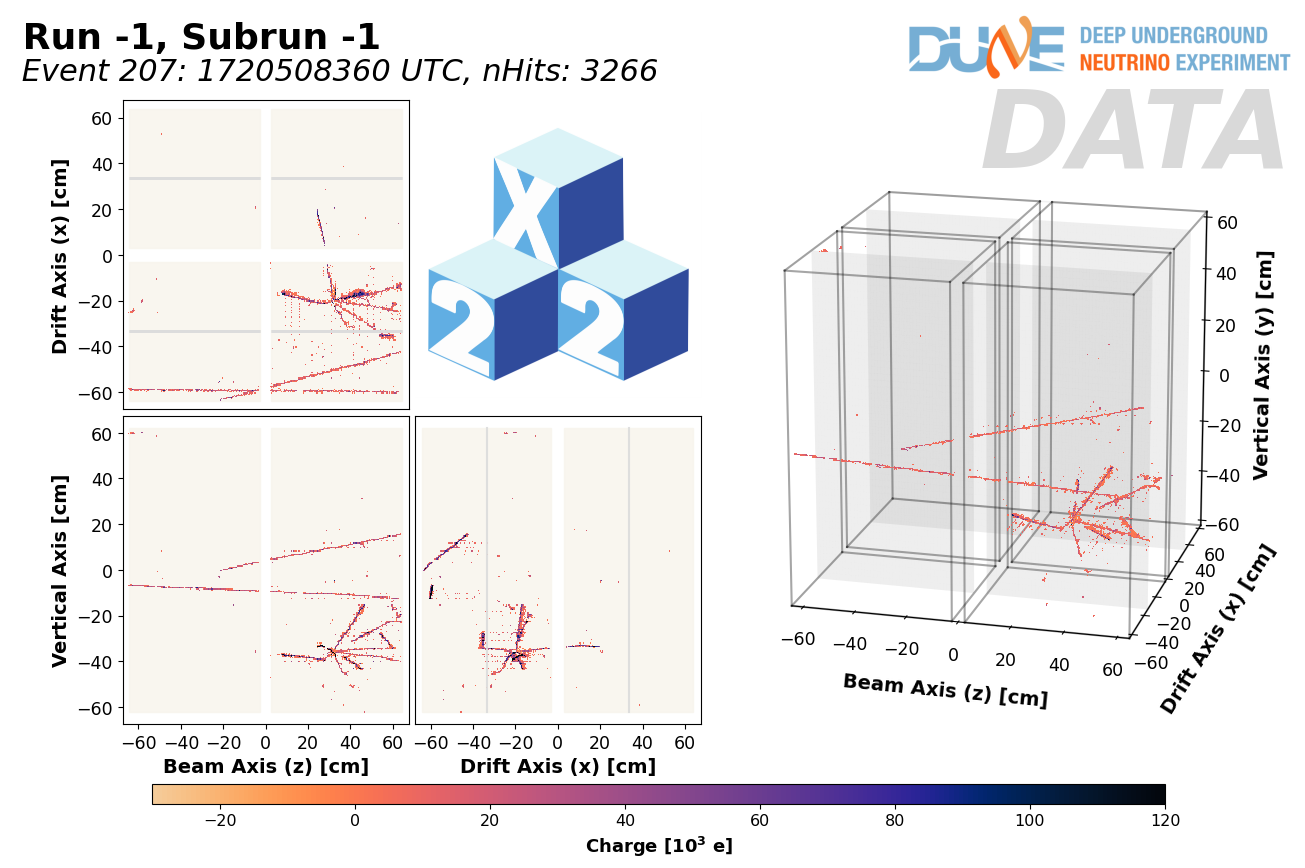

In [ ]:
evd = LArEventDisplay(filedir=file_path, filename=file_name, nhits_min=0, ntrigs=0, show_light=False, show_colorbars=True, filepath_mx2=mx2_file)
evd.run()
